In [97]:
# pipenv install sckit-learn scipy pandas matplotlib statsmodels fastapi uvicorn

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy.stats import shapiro, kstest, probplot
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot


## Carga dos dados

In [98]:
df_pontuacao = pd.read_csv('./datasets/pontuacao.csv')

In [99]:
df_pontuacao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   horas_estudo     57 non-null     float64
 1   pontuacao_teste  57 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 1.0 KB


In [100]:
df_pontuacao.head(10)

,horas_estudo,pontuacao_teste
0,0.5,25
1,1.0,50
2,1.9,55
3,3.0,65
4,4.0,70
5,5.0,74
6,6.0,78
7,7.2,85
8,8.0,88
9,9.0,92


In [101]:
df_pontuacao.tail(10)

,horas_estudo,pontuacao_teste
47,9.7,94
48,10.7,95
49,11.7,96
50,12.7,97
51,13.7,98
52,14.7,99
53,15.7,101
54,16.7,105
55,17.7,118
56,18.8,152


## EDA

In [102]:
# Medidas estatísticas das variáveis
df_pontuacao.describe()

,horas_estudo,pontuacao_teste
count,57.000000,57.000000
mean,9.382456,86.824561
std,5.596336,25.867190
min,0.500000,25.000000
25%,4.500000,72.000000
50%,9.500000,93.000000
75%,14.000000,99.000000
max,19.000000,155.000000


<Axes: xlabel='horas_estudo', ylabel='pontuacao_teste'>

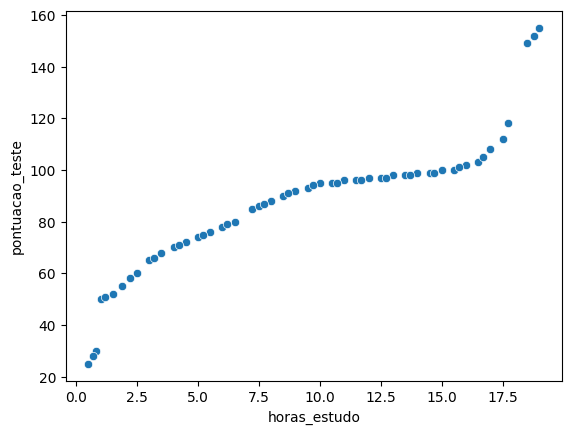

In [103]:
# Plot de dispersão
# x = horas_estudo
# y = pontuacao_teste
sns.scatterplot(data=df_pontuacao, x='horas_estudo', y='pontuacao_teste')

<Axes: ylabel='pontuacao_teste'>

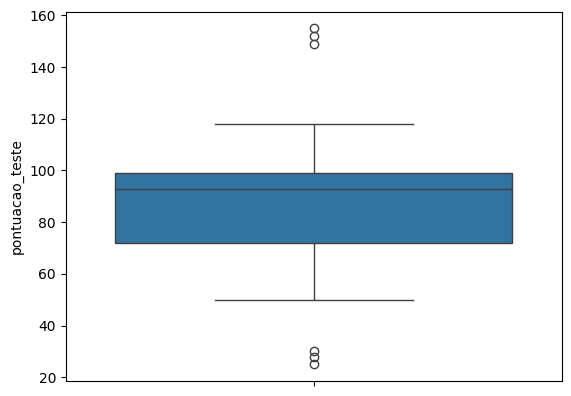

In [104]:
# Verificar se temos outliers
# Plot BoxPlot
sns.boxplot(data=df_pontuacao, y='pontuacao_teste')


<Axes: >

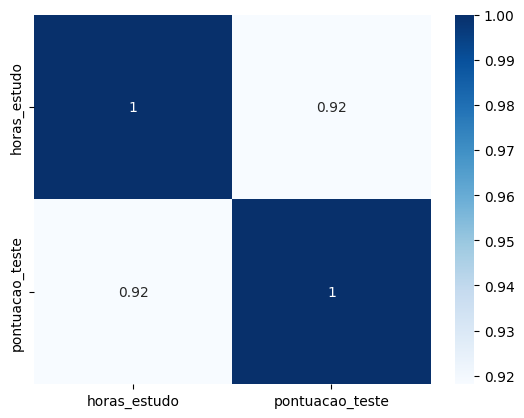

In [105]:
# Verificar Correlação - Pearson
sns.heatmap(df_pontuacao.corr('pearson'), annot=True, cmap='Blues')

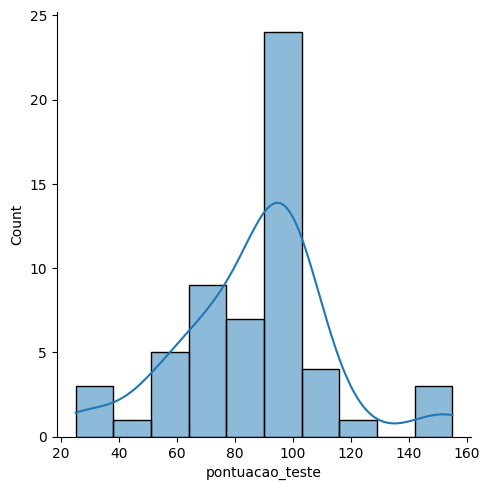

In [106]:
sns.displot(df_pontuacao, x='pontuacao_teste', kde=True)

## Treinar Modelo

In [107]:
# Dividir dataset entre treino e teste
# Quando temos apenas um feature, precisamos ajustar o shape
x = df_pontuacao['horas_estudo'].values.reshape(-1, 1)
y = df_pontuacao['pontuacao_teste'].values.reshape(-1, 1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=50)

In [108]:
# Instanciar o modelo
reg_modelo = LinearRegression()

In [109]:
# Treinar o modelo
reg_modelo.fit(x_train, y_train)

LinearRegression()

In [110]:
# Imprimir a equação da reta Y = ax + b
print("A equação é y = {:.4f}x + {:.4f}".format(reg_modelo.coef_[0][0], reg_modelo.intercept_[0]))

A equação é y = 4.1431x + 46.7484


## Validação do modelo - Métricas

In [111]:
# Predição dos valores com base nos conjuntos de teste
y_pred = reg_modelo.predict(x_test)

In [112]:
y_pred

array([[ 72.43556282],
       [ 50.89148134],
       [ 73.6784906 ],
       [ 51.72009985],
       [ 79.89312949],
       [ 90.25086097],
       [ 55.86319245],
       [ 64.14937763],
       [ 60.00628504],
       [100.60859245],
       [103.50875727],
       [ 82.7932943 ],
       [113.03787023],
       [124.63852949],
       [123.39560171],
       [120.08112764],
       [110.96632393],
       [ 96.46549986]])

In [113]:
# Calcular métricas R-squared ou coeficiente de determinação
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

In [114]:
# R2 representa a proporção na variação na variável dependente que é explicada pela variável independente
r2_score(y_test, y_pred)

0.8543032669640467

In [115]:
# Calcualar métrica MAE (Mean Absolute Error)
# MAE = Media (y_test - y_pred)
# É uma métrica fácil de interpretar, pois está na mesma unidade da variável alvo
# MAE é menos sensível a outliers
mean_absolute_error(y_test, y_pred)

7.569134908539502

In [116]:
# Calcular métrica MSE (Mean Squared Error)
# MSE = Media (y_test - y_pred)^2
# Não é uma métrica fácil de interpretar, pois está na unidade ao quadrado da variável alvo
# MSE é mais sensível a outliers e penaliza mais os erros maiores
mean_squared_error(y_test, y_pred)

111.972885832153

In [117]:
# Calcular métrica RMSE (Square Root Mean Squared Error)
# RMSE = raiz(Media (y_test - y_pred)^2)
# É uma métrica fácil de interpretar, pois está na mesma unidade da variável alvo
# RMSE é mais sensível a outliers e penaliza mais os erros maiores

root_mean_squared_error(y_test, y_pred)

10.581724142697777

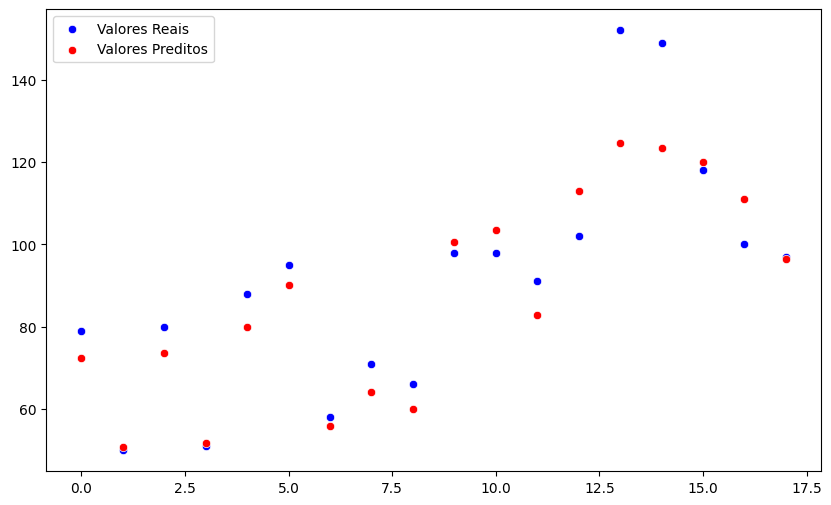

In [118]:
# Análise gráfica
x_axis = range(len(y_test))
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_axis, y=y_test.reshape(-1), color='blue', label='Valores Reais')
sns.scatterplot(x=x_axis, y=y_pred.reshape(-1), color='red', label='Valores Preditos')
plt.legend()
plt.show()

In [119]:
# Calcular os resíduos
residuals = y_test - y_pred
residuals

array([[  6.56443718],
       [ -0.89148134],
       [  6.3215094 ],
       [ -0.72009985],
       [  8.10687051],
       [  4.74913903],
       [  2.13680755],
       [  6.85062237],
       [  5.99371496],
       [ -2.60859245],
       [ -5.50875727],
       [  8.2067057 ],
       [-11.03787023],
       [ 27.36147051],
       [ 25.60439829],
       [ -2.08112764],
       [-10.96632393],
       [  0.53450014]])

In [120]:
# Calcular os residuos padronizados (standardization)
# Para cada elemento de um conjunto (X - média) / desvio padrão
from scipy.stats import zscore

In [121]:
residuals_std = zscore(residuals)
residuals_std

array([[ 0.27883414],
       [-0.47648242],
       [ 0.25422451],
       [-0.45912074],
       [ 0.43508926],
       [ 0.09493664],
       [-0.16970375],
       [ 0.30782593],
       [ 0.22101753],
       [-0.65043315],
       [-0.9442323 ],
       [ 0.44520299],
       [-1.50435518],
       [ 2.38566291],
       [ 2.20766395],
       [-0.5969987 ],
       [-1.49710724],
       [-0.33202438]])

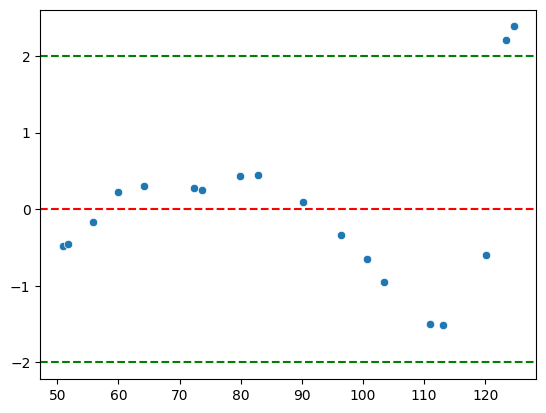

In [122]:
# Verificar linearidade do modelo:
# Se os resíduos estiver entre -2 e +2 (na escala padrão) - indica linearidade

# Verificar homogeneidade das variâncias (homoscedasticidade)
# Valores estiver em torno de reta, temos homoscedasticidade, caso contrário,
# se tivermos alguma tendência ou padrão (forman, um cone, funil) há heteroscedasticidade
sns.scatterplot(x=y_pred.reshape(-1), y=residuals_std.reshape(-1))
plt.axhline(0, color='red', linestyle='--')
plt.axhline(2, color='green', linestyle='--')
plt.axhline(-2, color='green', linestyle='--')
plt.show()

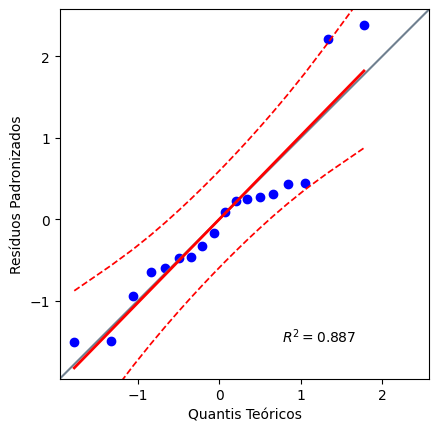

In [123]:
# Checar se residuos seguem uma distribuição normal
# QQ (Quantile-Quantile Plot) Plot, que avalia deuma amostra segue uma distribuição normal
import pingouin as pg
import matplotlib.pyplot as plt

pg.qqplot(residuals_std, dist='norm', confidence=0.95)

plt.xlabel('Quantis Teóricos')
plt.ylabel('Resíduos Padronizados')
plt.show()


In [124]:
# Teste de normalidade - shapiro wilk
# H0 - segue distribuição normal
# H1 - não segue distribuição normal
# Se p-value > 0.05, não rejeitamos H0, caso contrário rejeitamos
stat_shapiro, p_valor_shapiro = shapiro(residuals_std.reshape(-1))
print("Estatística do teste de Shapiro-Wilk: {:.4f}, p-valor: {:.4f}".format(stat_shapiro, p_valor_shapiro))

Estatística do teste de Shapiro-Wilk: 0.8920, p-valor: 0.0417


In [126]:
# Teste de normalidade - kolmongorov-shirnov
# H0 - segue distribuição normal
# H1 - não segue distribuição normal
# Se p-value > 0.05, não rejeitamos H0, caso contrário rejeitamos
stat_ks, p_valor_ks = kstest(residuals_std.reshape(-1), 'norm')
print("Estatística do teste de Kolmogorov-Smirnov: {:.4f}, p-valor: {:.4f}".format(stat_ks, p_valor_ks))

Estatística do teste de Kolmogorov-Smirnov: 0.2170, p-valor: 0.3174


## Fazer predições com modelo

In [127]:
# Se eu estudar 30 horas por semana, qual a minha previsão de nota no teste?
reg_modelo.predict([[30.45]])

array([[172.9055582]])

In [128]:
# Quantas horas eu preciso estudar para tirar 90 pontos no teste?
# y = ax + b
# y - b = ax
# (y - b) / a = x
# x = (y - b) / a
(600 - reg_modelo.intercept_[0]) / reg_modelo.coef_[0][0]

np.float64(133.53590315482512)

## Salvar modelo

In [129]:
import joblib
joblib.dump(reg_modelo, 'modelo_regressao_linear.pkl')

['modelo_regressao_linear.pkl']